In [ ]:
!pip install -q huggingface_hub datasets transformers sentence-transformers scikit-learn

import os
from huggingface_hub import login

HF_TOKEN = "add your hugging face token here"

os.environ["HF_TOKEN"] = HF_TOKEN
login(token=HF_TOKEN)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


# RQ2 — MiniLM Embedding-Based Thematic Clustering

**Research question:** Can sentence embeddings cluster climate policy documents into meaningful themes?

HF_TOKEN found in environment.


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loading dataset: ClimatePolicyRadar/all-document-text-data


README.md:   0%|          | 0.00/14.5k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

...

Encoding documents into embeddings...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding matrix shape: (15, 384)
Running K-Means with 3 clusters...
Silhouette score: 0.18697509
Saved main CSV: outputs/tables_csv/rq2_minilm_clustering_results.csv
Saved summary CSV: outputs/tables_csv/rq2_cluster_summary.csv


,doc_id,title,country,year,word_count,cluster_id,pca_x,pca_y,keyword_baseline_theme,cluster_majority_theme
0,AF.document.002MMUCR.n0001,Inception report,MUS,2011,10332,1,-0.442862,-0.177471,Adaptation,Adaptation
1,AF.document.002MMUCR.n0002,Mid-term evaluation report,MUS,2011,41952,1,-0.458457,-0.167598,Adaptation,Adaptation
2,AF.document.002MMUCR.n0003,Project completion report,MUS,2011,9498,1,-0.374517,-0.152712,Adaptation,Adaptation
3,AF.document.002MMUCR.n0004,Final evaluation report,MUS,2011,43622,1,-0.347596,-0.099806,Adaptation,Adaptation
4,AF.document.003MTMWR.n0000,Project document,TKM,2011,25104,0,0.424699,0.125520,Adaptation,Adaptation


,cluster_id,cluster_majority_theme,documents
0,0,Adaptation,4
1,1,Adaptation,8
2,2,Adaptation,3


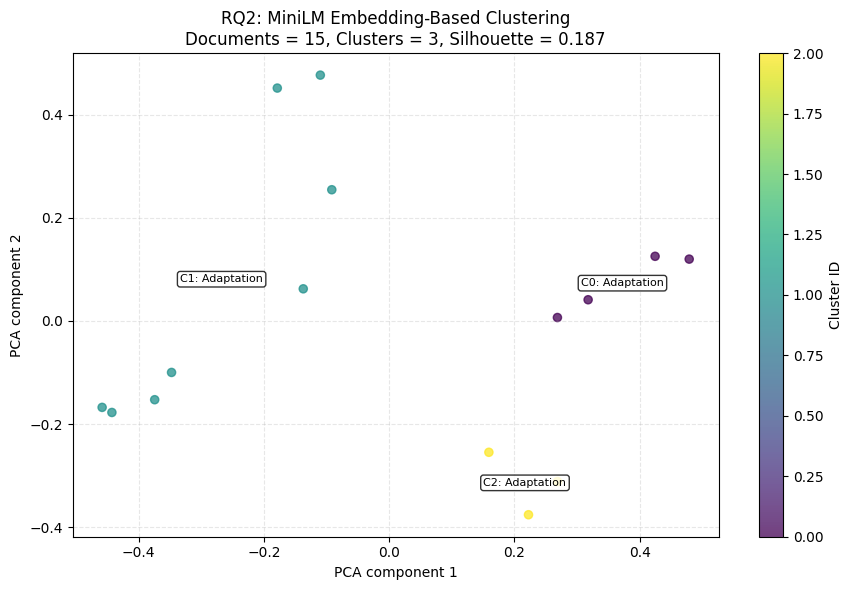

Saved PDF figure: outputs/figures_pdf/rq2_minilm_clustering_results.pdf

DONE. Your outputs are ready:
1. Main table:      outputs/tables_csv/rq2_minilm_clustering_results.csv
2. Summary table:   outputs/tables_csv/rq2_cluster_summary.csv
3. Figure:          outputs/figures_pdf/rq2_minilm_clustering_results.pdf

Current working folder: /content
Open this folder, then open the outputs folder.


In [3]:

# ============================================================
# RQ2 ONE-CLICK RUNNABLE NOTEBOOK
# MiniLM Embedding-Based Clustering of Climate Policy Documents
# ============================================================

import sys, os, re, json, getpass, subprocess, importlib.util, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# ---------- 0. Install/import packages ----------
def install_if_missing(import_name, pip_name=None):
    if pip_name is None:
        pip_name = import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", pip_name])

for import_name, pip_name in [
    ("datasets", "datasets"),
    ("huggingface_hub", "huggingface_hub"),
    ("sentence_transformers", "sentence-transformers"),
    ("sklearn", "scikit-learn"),
    ("matplotlib", "matplotlib"),
    ("pandas", "pandas"),
    ("numpy", "numpy"),
]:
    install_if_missing(import_name, pip_name)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from huggingface_hub import login
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ---------- 1. Settings ----------
DATASET_ID = "ClimatePolicyRadar/all-document-text-data"
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
MAX_ROWS = 30000       # increase for final experiment
MAX_DOCS = 300         # increase for final experiment
MIN_DOC_WORDS = 80
N_CLUSTERS = 6
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

OUTPUT_DIR = Path("outputs")
TABLE_DIR = OUTPUT_DIR / "tables_csv"
FIGURE_DIR = OUTPUT_DIR / "figures_pdf"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ---------- 2. Hugging Face token ----------
def setup_huggingface_token():
    token = os.environ.get("HF_TOKEN", "").strip()
    if token:
        print("HF_TOKEN found in environment.")
        try:
            login(token=token, add_to_git_credential=False)
        except Exception as e:
            print("Login warning:", e)
        return token
    print("HF_TOKEN not found. Paste your Hugging Face token below. It starts with hf_ .")
    token = getpass.getpass("HF_TOKEN: ").strip()
    if not token:
        raise ValueError("No token provided. Create a Hugging Face token and rerun this cell.")
    os.environ["HF_TOKEN"] = token
    try:
        login(token=token, add_to_git_credential=False)
    except Exception as e:
        print("Login warning:", e)
    return token

HF_TOKEN = setup_huggingface_token()

# ---------- 3. Helper functions ----------
def safe_to_str(x):
    if x is None:
        return ""
    if isinstance(x, (list, tuple, set)):
        return "; ".join(safe_to_str(i) for i in x)
    if isinstance(x, dict):
        return json.dumps(x, ensure_ascii=False)
    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass
    return str(x)

def clean_text(text):
    return re.sub(r"\s+", " ", safe_to_str(text)).strip()

def first_n_words(text, n=300):
    words = re.findall(r"\b\w+\b|[^\w\s]", clean_text(text))
    return " ".join(words[:n])

def get_value(row, key, default=None):
    if key in row:
        return row[key]
    value = row
    for part in key.split("."):
        if isinstance(value, dict) and part in value:
            value = value[part]
        else:
            return default
    return value

def extract_year(value):
    m = re.search(r"(19[5-9]\d|20[0-4]\d)", safe_to_str(value))
    return int(m.group(1)) if m else np.nan

def normalize_country(value):
    if value is None:
        return "Unknown"
    if isinstance(value, list) and value:
        first = value[0]
        if isinstance(first, dict):
            for k in ["display_value", "value", "name", "slug"]:
                if first.get(k):
                    return safe_to_str(first[k])
        return safe_to_str(first)
    if isinstance(value, dict):
        for k in ["display_value", "value", "name", "slug"]:
            if value.get(k):
                return safe_to_str(value[k])
    s = re.sub(r"[\[\]\{\}\"']", "", safe_to_str(value))
    s = re.sub(r"\s+", " ", s).strip()
    for sep in [";", "|", ","]:
        if sep in s:
            s = s.split(sep)[0].strip()
            break
    return s if s else "Unknown"

def dominant_keyword_theme(text):
    theme_keywords = {
        "Energy": ["energy", "renewable", "solar", "wind", "electricity", "power", "grid", "hydrogen"],
        "Transport": ["transport", "vehicle", "mobility", "rail", "aviation", "shipping", "public transport", "electric vehicle"],
        "Adaptation": ["adaptation", "resilience", "disaster", "flood", "drought", "risk", "vulnerability", "climate-resilient"],
        "Emissions Reduction": ["emission", "emissions", "carbon", "greenhouse gas", "ghg", "net zero", "decarbonization", "mitigation"],
        "Climate Finance": ["finance", "funding", "investment", "budget", "grant", "loan", "climate finance", "fund"],
        "Agriculture": ["agriculture", "farmer", "crop", "livestock", "soil", "food security", "forestry", "land use"],
    }
    text_l = clean_text(text).lower()
    counts = {}
    for theme, keywords in theme_keywords.items():
        counts[theme] = sum(len(re.findall(r"\b" + re.escape(kw.lower()) + r"\b", text_l)) for kw in keywords)
    return "Unknown" if max(counts.values()) == 0 else max(counts, key=counts.get)

# ---------- 4. Load and reconstruct documents ----------
def load_cpr_documents(max_rows=MAX_ROWS, max_docs=MAX_DOCS, min_doc_words=MIN_DOC_WORDS):
    print(f"Loading dataset: {DATASET_ID}")
    ds = load_dataset(DATASET_ID, split="train", streaming=True, token=HF_TOKEN)
    docs = {}
    for i, row in enumerate(ds):
        if i >= max_rows:
            break
        text = clean_text(get_value(row, "text_block.text", ""))
        if not text:
            continue
        doc_id = safe_to_str(get_value(row, "document_id", "")) or safe_to_str(get_value(row, "document_import_id", "")) or f"row_{i}"
        block_index = get_value(row, "text_block.index", i)
        try:
            block_index = int(block_index)
        except Exception:
            block_index = i
        if doc_id not in docs:
            docs[doc_id] = {
                "doc_id": doc_id,
                "title": safe_to_str(get_value(row, "document_metadata.document_title", "")),
                "country": normalize_country(get_value(row, "document_metadata.geographies", None)),
                "year": extract_year(get_value(row, "document_metadata.publication_ts", "")),
                "parts": []
            }
        docs[doc_id]["parts"].append((block_index, text))
    records = []
    for doc_id, d in docs.items():
        full_text = clean_text(" ".join(part for _, part in sorted(d["parts"], key=lambda x: x[0])))
        word_count = len(re.findall(r"\b\w+\b", full_text))
        if word_count >= min_doc_words:
            records.append({
                "doc_id": d["doc_id"], "title": d["title"], "country": d["country"],
                "year": d["year"], "full_text": full_text, "word_count": word_count
            })
    df = pd.DataFrame(records)
    if df.empty:
        raise ValueError("No documents reconstructed. Try lowering MIN_DOC_WORDS or increasing MAX_ROWS.")
    if len(df) > max_docs:
        df = df.sample(max_docs, random_state=RANDOM_SEED).reset_index(drop=True)
    else:
        df = df.reset_index(drop=True)
    print(f"Loaded reconstructed documents: {len(df)}")
    display(df[["doc_id", "title", "country", "year", "word_count"]].head())
    return df

df = load_cpr_documents()

# ---------- 5. Generate embeddings ----------
texts = [first_n_words(t, 300) for t in df["full_text"].tolist()]
print(f"Loading embedding model: {MODEL_NAME}")
model = SentenceTransformer(MODEL_NAME)
print("Encoding documents into embeddings...")
embeddings = model.encode(texts, show_progress_bar=True, batch_size=32, normalize_embeddings=True)
embeddings = np.array(embeddings)
print("Embedding matrix shape:", embeddings.shape)

# ---------- 6. Cluster using K-Means ----------
n_clusters = min(N_CLUSTERS, max(2, len(df)//5), len(df))
print(f"Running K-Means with {n_clusters} clusters...")
kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_SEED, n_init=10)
cluster_ids = kmeans.fit_predict(embeddings)
sil_score = silhouette_score(embeddings, cluster_ids) if len(set(cluster_ids)) > 1 and len(df) > n_clusters else np.nan
print("Silhouette score:", sil_score)

# ---------- 7. Reduce to 2D using PCA ----------
pca = PCA(n_components=2, random_state=RANDOM_SEED)
xy = pca.fit_transform(embeddings)

# ---------- 8. Save result tables ----------
result_table = df[["doc_id", "title", "country", "year", "word_count"]].copy()
result_table["cluster_id"] = cluster_ids
result_table["pca_x"] = xy[:, 0]
result_table["pca_y"] = xy[:, 1]
result_table["keyword_baseline_theme"] = [dominant_keyword_theme(t) for t in df["full_text"]]
cluster_theme_map = {}
for cid in sorted(result_table["cluster_id"].unique()):
    themes = result_table.loc[result_table["cluster_id"] == cid, "keyword_baseline_theme"]
    cluster_theme_map[cid] = themes.value_counts().index[0] if len(themes) else "Unknown"
result_table["cluster_majority_theme"] = result_table["cluster_id"].map(cluster_theme_map)

csv_path = TABLE_DIR / "rq2_minilm_clustering_results.csv"
result_table.to_csv(csv_path, index=False)
cluster_summary = result_table.groupby(["cluster_id", "cluster_majority_theme"]).size().reset_index(name="documents").sort_values("cluster_id")
summary_path = TABLE_DIR / "rq2_cluster_summary.csv"
cluster_summary.to_csv(summary_path, index=False)
print("Saved main CSV:", csv_path)
print("Saved summary CSV:", summary_path)
display(result_table.head())
display(cluster_summary)

# ---------- 9. Save PDF figure ----------
plt.figure(figsize=(9, 6))
scatter = plt.scatter(result_table["pca_x"], result_table["pca_y"], c=result_table["cluster_id"], alpha=0.75, s=35)
title = f"RQ2: MiniLM Embedding-Based Clustering\nDocuments = {len(result_table)}, Clusters = {n_clusters}"
if not np.isnan(sil_score):
    title += f", Silhouette = {sil_score:.3f}"
plt.title(title)
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.grid(True, linestyle="--", alpha=0.3)
plt.colorbar(scatter, label="Cluster ID")
for cid in sorted(result_table["cluster_id"].unique()):
    sub = result_table[result_table["cluster_id"] == cid]
    plt.text(sub["pca_x"].mean(), sub["pca_y"].mean(), f"C{cid}: {cluster_theme_map.get(cid,'Unknown')}", fontsize=8, ha="center", va="center", bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8))
pdf_path = FIGURE_DIR / "rq2_minilm_clustering_results.pdf"
plt.tight_layout()
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()
print("Saved PDF figure:", pdf_path)

# ---------- 10. Final message ----------
print("\nDONE. Your outputs are ready:")
print("1. Main table:     ", csv_path)
print("2. Summary table:  ", summary_path)
print("3. Figure:         ", pdf_path)
print("\nCurrent working folder:", os.getcwd())
print("Open this folder, then open the outputs folder.")
